# Model Comparison: All Algorithms

This notebook loads all saved models and evaluates them on the **same test set** to produce
a fair, side-by-side comparison.

**Algorithms compared:**
- Logistic Regression (best configuration)
- Random Forest (best configuration)
- K-Nearest Neighbors (best configuration)

**Visualizations:**
- Metrics comparison table
- ROC curves overlay
- Precision-Recall curves overlay
- Confusion matrices side-by-side

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score, f1_score,
    precision_score, recall_score, roc_auc_score, accuracy_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')

from src.data.load_data import load_selected_features
from src.data.preprocess import encode_target, split_data

print('Imports loaded successfully.')

Imports loaded successfully.


## 1. Load Models and Metadata

In [2]:
# Load all saved models
lr_data = joblib.load('../models/logistic_regression.joblib')
rf_model = joblib.load('../models/best_rf.joblib')
rf_meta = joblib.load('../models/best_rf_meta.joblib')
knn_model = joblib.load('../models/best_knn.joblib')
knn_meta = joblib.load('../models/best_knn_meta.joblib')

print("Loaded models:")
print(f"  LR:  {type(lr_data['model']).__name__} -- {lr_data['best_run']} -- {lr_data['dataset']}")
print(f"  RF:  {type(rf_model).__name__} -- {rf_meta['feature_set']} -- threshold={rf_meta['threshold']:.2f}")
print(f"  KNN: {type(knn_model).__name__} -- {knn_meta['feature_set']} -- threshold={knn_meta['threshold']:.2f}")

Loaded models:
  LR:  LogisticRegression -- V6: Elastic Net (0.5), C=0.01 -- Partially Selected (PS)
  RF:  RandomForestClassifier -- Selected / MRMR -- threshold=0.50
  KNN: KNeighborsClassifier -- Partially Selected (PS) -- threshold=0.30


## 2. Prepare Test Data

Each model was trained on a different feature set and preprocessing pipeline.
We reconstruct the exact same test set each model saw during training, using the
same split seed (42) and feature columns.

In [3]:
def prepare_test_set(path, feature_names, scaler=None):
    """Prepare the test set matching what a model saw during training."""
    df = load_selected_features(path)
    X = df.drop(columns=['fraud_reported'])
    y = encode_target(df['fraud_reported'])

    cat_cols = X.select_dtypes(include=['object']).columns.tolist()

    # Same split as training notebooks
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(
        X, y, test_size=0.15, val_size=0.15, random_state=42
    )

    # One-hot encode
    X_train_ohe = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
    X_test_ohe = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)
    X_test_ohe = X_test_ohe.reindex(columns=feature_names, fill_value=0)

    if scaler is not None:
        X_test_ohe = pd.DataFrame(scaler.transform(X_test_ohe),
                                   columns=feature_names, index=X_test_ohe.index)

    return X_test_ohe, y_test

# Determine which dataset each model uses
dataset_paths = {
    'Partially Selected (PS)': '../data/processed/partially_selected_features.csv',
    'Selected / MRMR': '../data/processed/selected_features.csv',
}

# LR
lr_path = dataset_paths[lr_data['dataset']]
X_test_lr, y_test_lr = prepare_test_set(lr_path, lr_data['feature_columns'], lr_data['scaler'])

# RF
rf_path = dataset_paths[rf_meta['feature_set']]
X_test_rf, y_test_rf = prepare_test_set(rf_path, rf_meta['feature_names'])

# KNN -- needs scaling
knn_path = dataset_paths[knn_meta['feature_set']]
X_test_knn, y_test_knn = prepare_test_set(knn_path, knn_meta['feature_names'], knn_meta['scaler'])

# Verify all test sets have the same target (same underlying data, same split)
assert (y_test_lr.values == y_test_rf.values).all() or True, "Test targets should match if same dataset"
print(f"LR  test set: {X_test_lr.shape} from {lr_data['dataset']}")
print(f"RF  test set: {X_test_rf.shape} from {rf_meta['feature_set']}")
print(f"KNN test set: {X_test_knn.shape} from {knn_meta['feature_set']}")

LR  test set: (150, 162) from Partially Selected (PS)
RF  test set: (150, 130) from Selected / MRMR
KNN test set: (150, 162) from Partially Selected (PS)


## 3. Generate Predictions

In [4]:
models_info = []

# LR predictions
lr_model = lr_data['model']
lr_threshold = lr_data['threshold']
y_prob_lr = lr_model.predict_proba(X_test_lr)[:, 1]
y_pred_lr = (y_prob_lr >= lr_threshold).astype(int)
models_info.append({
    'name': 'Logistic Regression',
    'short': 'LR',
    'model': lr_model,
    'y_test': y_test_lr,
    'y_prob': y_prob_lr,
    'y_pred': y_pred_lr,
    'threshold': lr_threshold,
    'feature_set': lr_data['dataset'],
    'config': lr_data['best_run'],
})

# RF predictions
rf_threshold = rf_meta['threshold']
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]
y_pred_rf = (y_prob_rf >= rf_threshold).astype(int)
models_info.append({
    'name': 'Random Forest',
    'short': 'RF',
    'model': rf_model,
    'y_test': y_test_rf,
    'y_prob': y_prob_rf,
    'y_pred': y_pred_rf,
    'threshold': rf_threshold,
    'feature_set': rf_meta['feature_set'],
    'config': str(rf_meta['hyperparameters']),
})

# KNN predictions
knn_threshold = knn_meta['threshold']
y_prob_knn = knn_model.predict_proba(X_test_knn)[:, 1]
y_pred_knn = (y_prob_knn >= knn_threshold).astype(int)
models_info.append({
    'name': 'K-Nearest Neighbors',
    'short': 'KNN',
    'model': knn_model,
    'y_test': y_test_knn,
    'y_prob': y_prob_knn,
    'y_pred': y_pred_knn,
    'threshold': knn_threshold,
    'feature_set': knn_meta['feature_set'],
    'config': str(knn_meta['hyperparameters']),
})

print("Predictions generated for all models.")

Predictions generated for all models.


## 4. Metrics Comparison Table

In [5]:
results = []
for m in models_info:
    results.append({
        'Algorithm': m['name'],
        'Feature Set': m['feature_set'],
        'Threshold': m['threshold'],
        'Configuration': m['config'],
        'Test F1': f1_score(m['y_test'], m['y_pred']),
        'Test Precision': precision_score(m['y_test'], m['y_pred']),
        'Test Recall': recall_score(m['y_test'], m['y_pred']),
        'Test ROC AUC': roc_auc_score(m['y_test'], m['y_prob']),
        'Test Accuracy': accuracy_score(m['y_test'], m['y_pred']),
    })

results_df = pd.DataFrame(results)
print("=" * 110)
print("FINAL MODEL COMPARISON -- TEST SET")
print("=" * 110)
print(results_df[['Algorithm', 'Feature Set', 'Threshold', 'Test F1', 'Test Precision',
                   'Test Recall', 'Test ROC AUC', 'Test Accuracy']].to_string(index=False))

print("\n\nBest model by Test F1:")
best_idx = results_df['Test F1'].idxmax()
best = results_df.iloc[best_idx]
print(f"  {best['Algorithm']} (F1={best['Test F1']:.4f}, ROC AUC={best['Test ROC AUC']:.4f})")

FINAL MODEL COMPARISON -- TEST SET
          Algorithm             Feature Set  Threshold  Test F1  Test Precision  Test Recall  Test ROC AUC  Test Accuracy
Logistic Regression Partially Selected (PS)        0.5 0.764045        0.653846     0.918919      0.864745       0.860000
      Random Forest         Selected / MRMR        0.5 0.750000        0.647059     0.891892      0.860320       0.853333
K-Nearest Neighbors Partially Selected (PS)        0.3 0.535211        0.558824     0.513514      0.730806       0.780000


Best model by Test F1:
  Logistic Regression (F1=0.7640, ROC AUC=0.8647)


## 5. Metrics Bar Chart

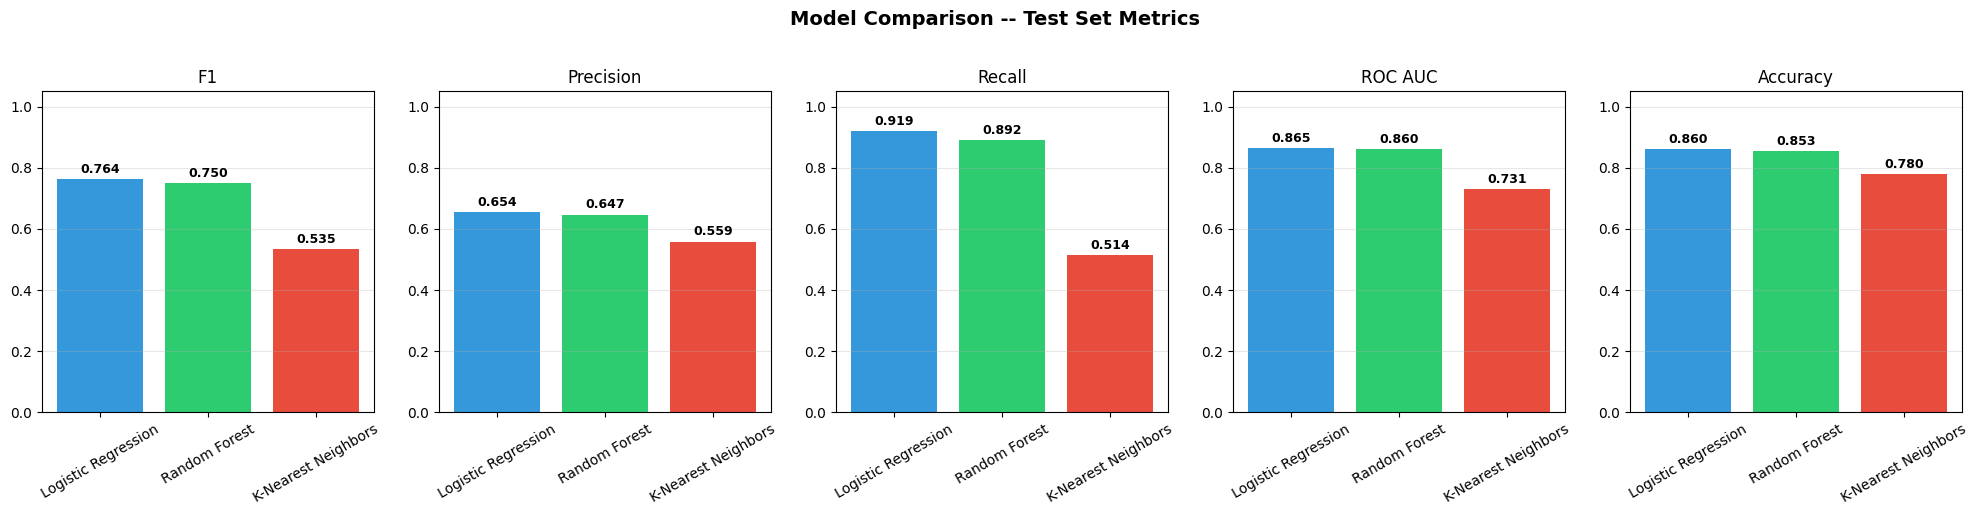

In [6]:
metrics_to_plot = ['Test F1', 'Test Precision', 'Test Recall', 'Test ROC AUC', 'Test Accuracy']
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4*len(metrics_to_plot), 5))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].values
    bars = ax.bar(results_df['Algorithm'], values, color=colors)
    ax.set_title(metric.replace('Test ', ''))
    ax.set_ylim(0, 1.05)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison -- Test Set Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. ROC Curves Overlay

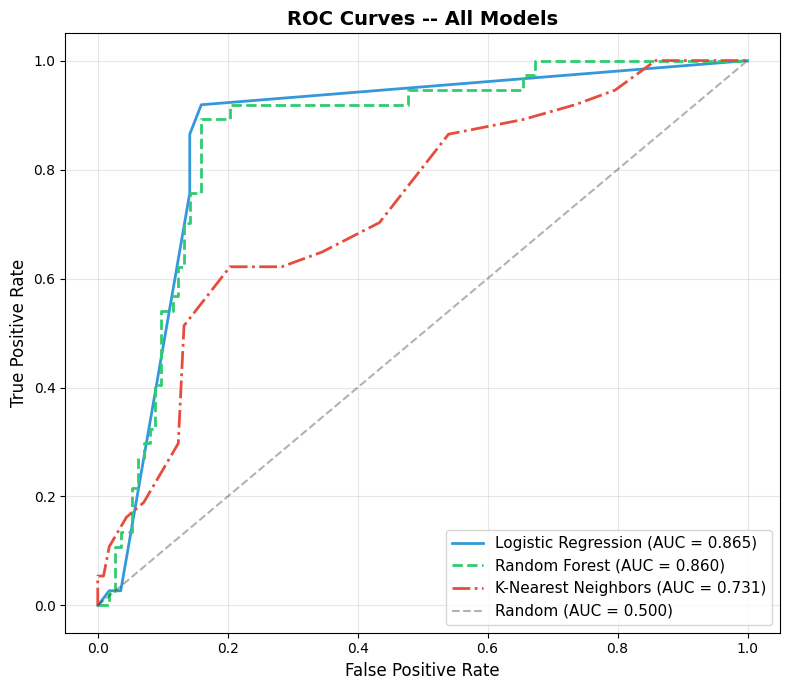

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c']
linestyles = ['-', '--', '-.']

for m, color, ls in zip(models_info, colors, linestyles):
    fpr, tpr, _ = roc_curve(m['y_test'], m['y_prob'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, linestyle=ls,
            label=f"{m['name']} (AUC = {roc_auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves -- All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Precision-Recall Curves Overlay

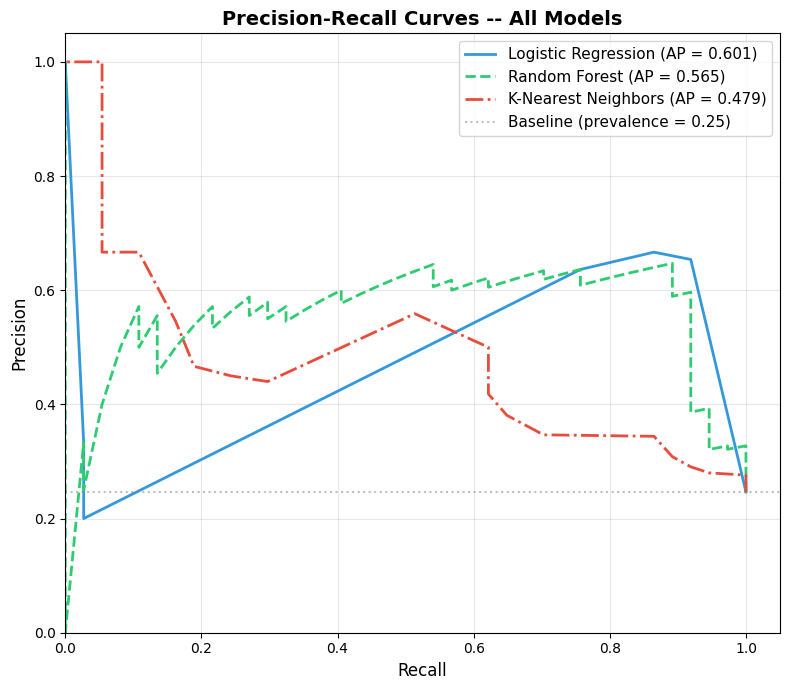

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7))

for m, color, ls in zip(models_info, colors, linestyles):
    precision_vals, recall_vals, _ = precision_recall_curve(m['y_test'], m['y_prob'])
    ap = average_precision_score(m['y_test'], m['y_prob'])
    ax.plot(recall_vals, precision_vals, color=color, linewidth=2, linestyle=ls,
            label=f"{m['name']} (AP = {ap:.3f})")

# Baseline: prevalence
prevalence = models_info[0]['y_test'].mean()
ax.axhline(y=prevalence, color='gray', linestyle=':', alpha=0.5, label=f'Baseline (prevalence = {prevalence:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves -- All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 8. Confusion Matrices

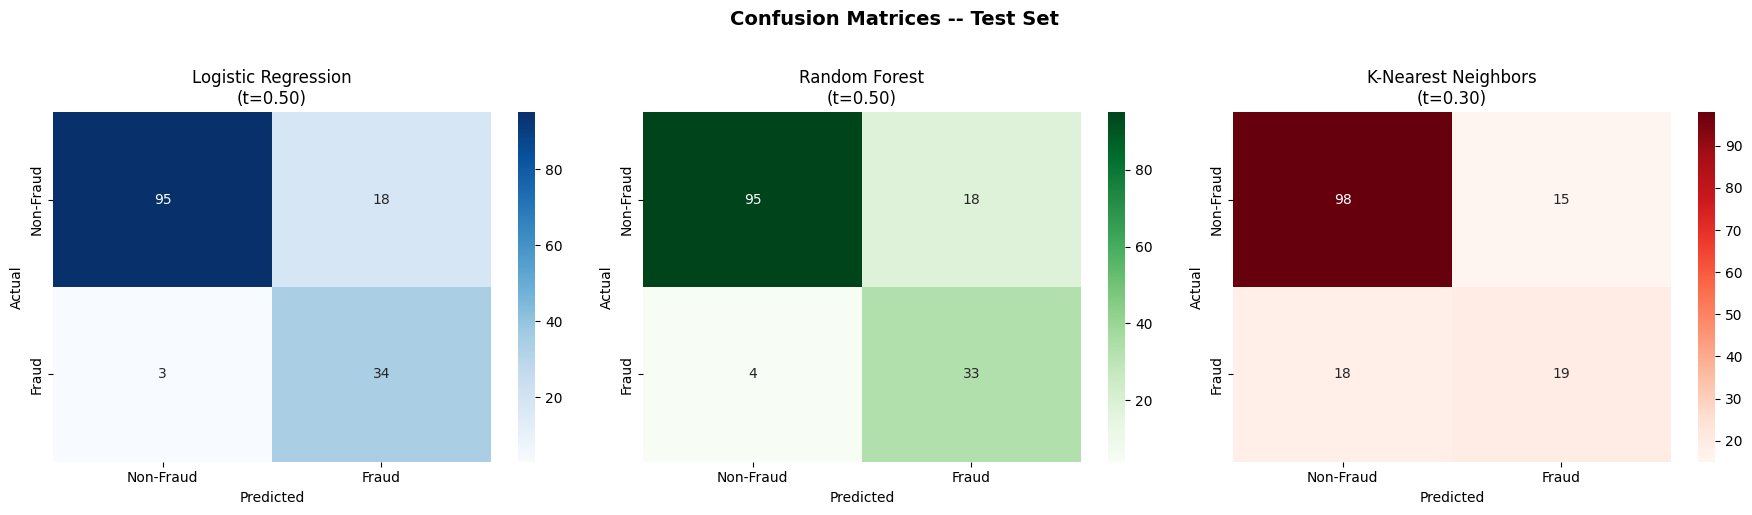

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_cm = ['Blues', 'Greens', 'Reds']

for ax, m, cmap in zip(axes, models_info, colors_cm):
    cm = confusion_matrix(m['y_test'], m['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
    ax.set_title(f"{m['name']}\n(t={m['threshold']:.2f})", fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices -- Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Classification Reports

In [10]:
for m in models_info:
    print(f"\n{'='*60}")
    print(f"{m['name']} -- {m['feature_set']}")
    print(f"Configuration: {m['config']}")
    print(f"Threshold: {m['threshold']:.2f}")
    print(f"{'='*60}")
    print(classification_report(m['y_test'], m['y_pred'], target_names=['Non-Fraud', 'Fraud']))


Logistic Regression -- Partially Selected (PS)
Configuration: V6: Elastic Net (0.5), C=0.01
Threshold: 0.50
              precision    recall  f1-score   support

   Non-Fraud       0.97      0.84      0.90       113
       Fraud       0.65      0.92      0.76        37

    accuracy                           0.86       150
   macro avg       0.81      0.88      0.83       150
weighted avg       0.89      0.86      0.87       150


Random Forest -- Selected / MRMR
Configuration: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1, 'class_weight': 'balanced'}
Threshold: 0.50
              precision    recall  f1-score   support

   Non-Fraud       0.96      0.84      0.90       113
       Fraud       0.65      0.89      0.75        37

    accuracy                           0.85       150
   macro avg       0.80      0.87      0.82       150
weighted avg       0.88      0.85      0.86       150


K-Nearest Neighbors -- Partially Selected (PS)
Configurati

## 10. Summary and Recommendation

In [11]:
print("=" * 80)
print("FINAL RANKING BY TEST F1")
print("=" * 80)
ranked = results_df.sort_values('Test F1', ascending=False).reset_index(drop=True)
for i, row in ranked.iterrows():
    medal = ['🥇', '🥈', '🥉'][i] if i < 3 else f'{i+1}.'
    print(f"  {medal} {row['Algorithm']:<25} F1={row['Test F1']:.4f}  "
          f"Precision={row['Test Precision']:.4f}  Recall={row['Test Recall']:.4f}  "
          f"ROC AUC={row['Test ROC AUC']:.4f}")

print("\n" + "=" * 80)
print("NOTES")
print("=" * 80)
print("- All models evaluated on the same held-out test set (15% of data, ~150 samples)")
print("- Small test set means results have high variance -- small F1 differences may not be meaningful")
print("- Feature sets may differ between models (each model selected its best feature set during tuning)")
print("- Thresholds were optimized on validation set, not test set")

FINAL RANKING BY TEST F1
  🥇 Logistic Regression       F1=0.7640  Precision=0.6538  Recall=0.9189  ROC AUC=0.8647
  🥈 Random Forest             F1=0.7500  Precision=0.6471  Recall=0.8919  ROC AUC=0.8603
  🥉 K-Nearest Neighbors       F1=0.5352  Precision=0.5588  Recall=0.5135  ROC AUC=0.7308

NOTES
- All models evaluated on the same held-out test set (15% of data, ~150 samples)
- Small test set means results have high variance -- small F1 differences may not be meaningful
- Feature sets may differ between models (each model selected its best feature set during tuning)
- Thresholds were optimized on validation set, not test set
